In [14]:
import torch
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import pandas as pd
import numpy as np
from rdkit import Chem

class CTDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)
    
    def mol_to_graph(self, smiles):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise ValueError(f"Invalid SMILES string: {smiles}")

        edge_index = []
        node_features = []
        edge_features = []

        for bond in mol.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()

            bond_type = bond.GetBondTypeAsDouble()  # 1.0, 2.0, 3.0, 1.5 (aromatic)
            is_conjugated = bond.GetIsConjugated()
            is_in_ring = bond.IsInRing()

            edge_feat = [bond_type, float(is_conjugated), float(is_in_ring)]

            # Add both directions
            edge_index.append((i, j))
            edge_index.append((j, i))
            edge_features.append(edge_feat)
            edge_features.append(edge_feat)

        # one hot encoding of atom types
        for atom in mol.GetAtoms():
            atom_type = atom.GetAtomicNum()
            aromatic = atom.GetIsAromatic()
            formal_charge = atom.GetFormalCharge()
            hybridization = int(atom.GetHybridization())
            degree = atom.GetDegree()
            valence = atom.GetTotalValence()

            node_features.append([atom_type, aromatic, formal_charge, hybridization, degree, valence])  

        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_features, dtype=torch.float)
        x = torch.tensor(node_features, dtype=torch.float)

        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # fetch graph data
        smiles = row['Canonical SMILES']
        graph_data = self.mol_to_graph(smiles)

        smi_ted_embedding = np.array(row['X_smi_ted'], dtype=np.float32)   
        smi_ted_embedding = torch.tensor(smi_ted_embedding, dtype=torch.float)

        il_type = torch.tensor(row['il_type'], dtype=torch.float)

        # Get labels 
        label = torch.tensor(row['target'], dtype=torch.float)

        return graph_data, smi_ted_embedding, il_type, label

def main():
    dataset_path = "./ct.parquet"
    df = pd.read_parquet(dataset_path)

    df['X_smi_ted'] = df['X_smi_ted'].apply(lambda x: np.array(x))

    # Create dataset
    dataset = CTDataset(df)
    print("node feature dims", dataset[0][0].x.shape[1])
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    # sample one datapoint from dataset and print node feat dims
    for graph_data, smi_ted_embedding, il_type, labels in dataloader:
        print(f"Graph data: {graph_data}")

        print(f"SMI-TED Embedding shape: {smi_ted_embedding.shape}")
        print(f"IL Type shape: {il_type.shape}")
        print(f"Labels shape: {labels.shape}")
        break

if __name__ == "__main__":
    main()

node feature dims 6
Graph data: DataBatch(x=[1033, 6], edge_index=[2, 2074], edge_attr=[2074, 3], batch=[1033], ptr=[33])
SMI-TED Embedding shape: torch.Size([32, 768])
IL Type shape: torch.Size([32, 17])
Labels shape: torch.Size([32])


In [15]:
import torch 
import torch.nn as nn
from torch_geometric.nn import GATConv, GINConv, global_mean_pool, AttentionalAggregation, MFConv, global_add_pool, GraphNorm

class GAT(nn.Module):
    # captures connectivity importances
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(GAT, self).__init__()
        self.conv1 = GATConv(in_channels, hidden_dim)
        self.conv2 = GATConv(hidden_dim, hidden_dim)
        self.conv3 = GATConv(hidden_dim, out_channels)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = nn.GELU()(x)
        x = nn.Dropout(0.2)(x)  # Dropout for regularization
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = nn.GELU()(x)
        x = nn.Dropout(0.2)(x)  # Dropout for regularization
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = nn.GELU()(x)
        return x
    
class GIN(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_dim):
        super(GIN, self).__init__()

        # MLP for first GIN layer
        self.mlp1 = nn.Sequential(
            nn.Linear(in_channels, hidden_dim*2),
            nn.BatchNorm1d(hidden_dim*2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim*2, hidden_dim)
        )

        # MLP for second GIN layer
        self.mlp2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim*2),
            nn.BatchNorm1d(hidden_dim*2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim*2, hidden_dim)
        )

        self.conv1 = GINConv(self.mlp1)
        self.conv2 = GINConv(self.mlp2)
        self.out_lin = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = nn.GELU()(x)
        x = nn.Dropout(0.2)(x)

        x = self.conv2(x, edge_index)
        x = nn.GELU()(x)
        x = self.out_lin(x)
        return x


class MFNet(nn.Module):
    # captures connectivity importances
    def __init__(self, in_channels, out_channels):
        super(MFNet, self).__init__()
        self.conv1 = MFConv(in_channels, 64)
        self.norm1 = GraphNorm(64)  # Normalization layer
        self.conv2 = MFConv(64, 64)
        self.norm2 = GraphNorm(64)
        self.conv3 = MFConv(64, out_channels)


    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        x = self.norm2(x)
        x = torch.relu(x)
        x = self.conv3(x, edge_index)
        return x
    
# class GatedFusion(nn.Module):
#     def __init__(self, out_channels):
#         super().__init__()
#         self.gate = nn.Sequential(
#             nn.Linear(out_channels, 1),   # score per branch
#         )

#     def forward(self, x):
#         # x: [batch_size, num_branches, out_channels]
#         scores = self.gate(x).squeeze(-1)          # [batch_size, num_branches]
#         weights = torch.softmax(scores, dim=-1)    # normalize across branches
#         out = torch.sum(weights.unsqueeze(-1) * x, dim=1)  # [batch_size, out_channels]
#         return out

    
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, smi_ted_dim, il_dim, out_dim, hidden_dim=128):
        super(MLP, self).__init__()

        # Deep tower for SMILES embeddings
        self.smi_ted_fc = nn.Sequential(
            nn.Linear(smi_ted_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # Deep tower for il_type embeddings
        self.il_fc = nn.Sequential(
            nn.Linear(il_dim, il_dim),
            nn.GELU(),
        )

        # Deep final layers
        self.deep_fc = nn.Sequential(
            nn.Linear(hidden_dim + il_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, out_dim)
        )

        # Wide part: linear layer directly from raw features to output
        self.wide_fc = nn.Sequential(
            nn.Linear(smi_ted_dim + il_dim, out_dim * 5),
            nn.BatchNorm1d(out_dim * 5),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(out_dim * 5, out_dim)
        )

    def forward(self, smi_ted, il_type):
        # Deep path
        x1 = self.smi_ted_fc(smi_ted)
        x2 = self.il_fc(il_type)
        deep_input = torch.cat([x1, x2], dim=-1)
        deep_out = self.deep_fc(deep_input)

        # Wide path (raw inputs directly)
        wide_input = torch.cat([smi_ted, il_type], dim=-1)
        wide_out = self.wide_fc(wide_input)

        # Combine wide + deep (sum is typical)
        out = wide_out + deep_out
        return out


class twoTrackNetwork(nn.Module):

    def __init__(self, in_channels, out_channels, smi_ted_dim, il_dim, hidden_dim):
        super(twoTrackNetwork, self).__init__()
        self.gat = GAT(in_channels, out_channels, hidden_dim)
        self.gin = GIN(in_channels, hidden_dim=hidden_dim, out_dim=out_channels)
        self.mlp = MLP(smi_ted_dim, il_dim, hidden_dim=hidden_dim, out_dim=out_channels)
        self.mf_net = MFNet(in_channels, out_channels)
        # self.branch_fusion = GatedFusion(out_channels)
        self.branch_attn = nn.MultiheadAttention(embed_dim=out_channels, num_heads=4, batch_first=True)

        self.final_mlp = nn.Sequential(
            nn.Linear(out_channels, out_channels),
            nn.BatchNorm1d(out_channels),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(out_channels, out_channels),
            nn.GELU(),
            nn.Linear(out_channels, 1)
        )

    def forward(self, graph_data, smi_ted, il_type):
        # Graph data
        x, edge_index, batch = graph_data.x, graph_data.edge_index, graph_data.batch
        mf_out = self.mf_net(x, edge_index)
        gat_out = self.gat(x, edge_index)
        gin_out = self.gin(x, edge_index)

        # Pooling
        gat_pooled = global_mean_pool(gat_out, batch)
        gin_pooled = global_add_pool(gin_out, batch)
        mf_pooled = global_add_pool(mf_out, batch)
        embedding_out = self.mlp(smi_ted, il_type)

        # Stack branch outputs shape [batch_size, num_branches, out_channels] for attention
        stacked = torch.stack([
            mf_pooled,
            gat_pooled,
            gin_pooled,
            embedding_out
        ], dim=1)

        out, _ = self.branch_attn(stacked, stacked, stacked)
        out = out.mean(dim=1)

        # Final prediction head
        out = self.final_mlp(out)

        return out
    
if __name__ == "__main__":
    # Example usage
    model = twoTrackNetwork(in_channels=10, out_channels=32, smi_ted_dim=768, il_dim=17, hidden_dim=64)
    print(model)
    print("Model parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

twoTrackNetwork(
  (gat): GAT(
    (conv1): GATConv(10, 64, heads=1)
    (conv2): GATConv(64, 64, heads=1)
    (conv3): GATConv(64, 32, heads=1)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (gin): GIN(
    (mlp1): Sequential(
      (0): Linear(in_features=10, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.2, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
    )
    (mlp2): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.2

Dataset loaded

Input channels: 768, 6
Output channels: 128
Loaders created. Starting training...

Model parameters: 1404211
epoch: 0, train loss: 0.626, val loss: 0.394
epoch: 1, train loss: 0.456, val loss: 0.382
epoch: 2, train loss: 0.395, val loss: 0.306
epoch: 3, train loss: 0.345, val loss: 0.281
epoch: 4, train loss: 0.297, val loss: 0.305
epoch: 5, train loss: 0.280, val loss: 0.280
epoch: 6, train loss: 0.273, val loss: 0.336
epoch: 7, train loss: 0.246, val loss: 0.265
epoch: 8, train loss: 0.243, val loss: 0.253
epoch: 9, train loss: 0.248, val loss: 0.262
epoch: 10, train loss: 0.233, val loss: 0.248
epoch: 11, train loss: 0.233, val loss: 0.232
epoch: 12, train loss: 0.219, val loss: 0.254
epoch: 13, train loss: 0.215, val loss: 0.206
epoch: 14, train loss: 0.216, val loss: 0.213
epoch: 15, train loss: 0.207, val loss: 0.240
epoch: 16, train loss: 0.212, val loss: 0.258
epoch: 17, train loss: 0.219, val loss: 0.224
epoch: 18, train loss: 0.214, val loss: 0.233
epoch: 19, 

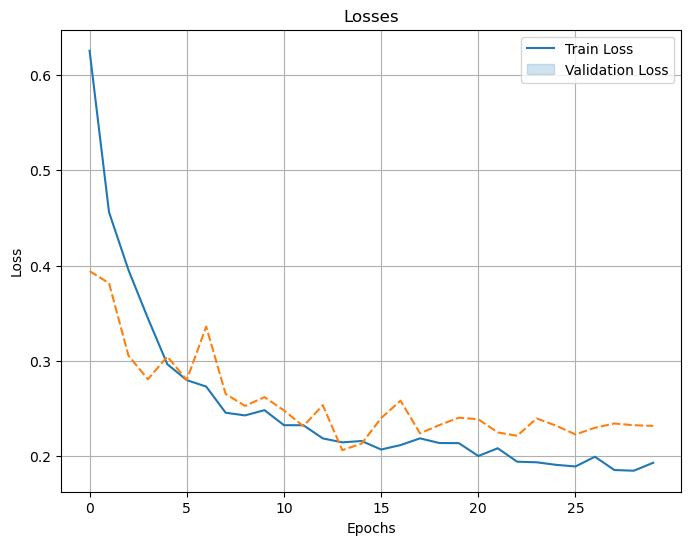

In [16]:
import torch
from torch_geometric.loader import DataLoader
import pandas as pd
import numpy as np
from torch.utils.data import random_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr
import os 
from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')

torch.manual_seed(42)

def iterate(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for graph_data, smi_ted, il_type, labels in train_loader:
        graph_data = graph_data.to(device)
        smi_ted = smi_ted.to(device)
        il_type = il_type.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(graph_data, smi_ted, il_type)
        loss = criterion(outputs.view(-1), labels.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for graph_data, smi_ted, il_type, labels in val_loader:
            graph_data = graph_data.to(device)
            smi_ted = smi_ted.to(device)
            il_type = il_type.to(device)
            il_type = il_type.to(device)
            labels = labels.to(device)

            outputs = model(graph_data, smi_ted, il_type)
            loss = criterion(outputs.view(-1), labels.view(-1))
            total_loss += loss.item()

    return total_loss / len(val_loader)

def evaluate_regression(y_true, y_pred):
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.detach().cpu().numpy()
    if isinstance(y_pred, torch.Tensor):
        y_pred = y_pred.detach().cpu().numpy()

    y_true = np.array(y_true, dtype=float).flatten()
    y_pred = np.array(y_pred, dtype=float).flatten()

    if np.any(np.isnan(y_true)) or np.any(np.isnan(y_pred)):
        raise ValueError("NaNs detected in y_true or y_pred!")
    if np.any(np.isinf(y_true)) or np.any(np.isinf(y_pred)):
        raise ValueError("Infs detected in y_true or y_pred!")
    assert y_true.shape == y_pred.shape, f"Shape mismatch: {y_true.shape} vs {y_pred.shape}"

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    pearson_r, _ = pearsonr(y_true, y_pred)
    spearman_r, _ = spearmanr(y_true, y_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Pearson r: {pearson_r:.4f}")
    print(f"Spearman rho: {spearman_r:.4f}")

    return f"RMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}\nPearson r: {pearson_r:.4f}\nSpearman rho: {spearman_r:.4f}"

def make_plots(y_true, y_pred, run_name):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'k--', lw=2)  # Line y=x
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title("Predictions vs True Values")
    plt.savefig(f"results/predictions_{run_name}.png")
    plt.close()

    plt.figure(figsize=(8, 6))
    residuals = y_true.flatten() - y_pred.flatten()
    plt.scatter(y_pred.flatten(), residuals)
    plt.axhline(0, color='black', linestyle='--')
    plt.title("Residuals vs Predicted Values")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.savefig(f"results/residuals_{run_name}.png")
    plt.close()

def main():
    results_path = "./results"
    model_dir = "./models"

    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(results_path, exist_ok=True)
    dataset_path = "./ct.parquet"
    ct = pd.read_parquet(dataset_path)
    print("Dataset loaded\n")

    ct['X_smi_ted'] = ct['X_smi_ted'].apply(lambda x: np.array(x))

    # Create dataset
    dataset = CTDataset(ct)

    # dataset used:
    df = ct
    run_name = "ct_smi"

    # split the dataset
    train, test, val = random_split(
        dataset, 
        lengths=[0.75, 0.15, 0.1],
        generator=torch.Generator().manual_seed(42)
    )

    trainLoader = DataLoader(train, batch_size=32, shuffle=True)
    testLoader = DataLoader(test, batch_size=32, shuffle=False)
    valLoader = DataLoader(val, batch_size=32, shuffle=False)

    smi_ted_dim = df['X_smi_ted'].iloc[0].shape[0]
    il_dim = df['il_type'].iloc[0].shape[0]
    in_channels = dataset[0][0].x.shape[1]

    # ---------
    out_channels = 128
    hidden_dim = 128
    # ---------

    print(f"Input channels: {smi_ted_dim}, {in_channels}")
    print(f"Output channels: {out_channels}")

    def train_model(trainLoader, valLoader, smi_ted_dim, in_channels, out_channels, il_dim, hidden_dim):

        print("Loaders created. Starting training...\n")
        model = twoTrackNetwork(
            in_channels=in_channels,
            smi_ted_dim=smi_ted_dim,
            out_channels=out_channels, 
            il_dim=il_dim,
            hidden_dim=hidden_dim
        )
        print("Model parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

        optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4, weight_decay=1e-6)
        criterion = torch.nn.MSELoss()
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)

        epochs = 30
        
        history = []
        for epoch in range(epochs):
            train_loss = iterate(model, trainLoader, optimizer, criterion, device)
            val_loss = evaluate(model, valLoader, criterion, device)

            losses = {
                'train_loss': train_loss,
                'val_loss': val_loss
            }
            print(f"epoch: {epoch}, train loss: {losses['train_loss'] :.3f}, val loss: {losses['val_loss'] :.3f}")
            history.append(losses)

        print("Training Complete")

        losses_df = pd.DataFrame(history)
        plt.figure(figsize=(8, 6))
        plt.title("Losses")
        sns.lineplot(losses_df)
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend(['Train Loss', 'Validation Loss'])
        plt.xticks(range(0, epochs, 5))
        plt.grid()
        plt.savefig(f"results/losses_{run_name}.png")
        return history, model

    history, model = train_model(trainLoader, valLoader, smi_ted_dim, in_channels, out_channels, il_dim, hidden_dim)

    # test the model on the test data:

    criterion = torch.nn.MSELoss()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    test_loss = evaluate(model, testLoader, criterion, device)
    print(f'Test loss: {test_loss}')
    y_true = []
    y_pred = []

    model.eval()
    with torch.no_grad():
        for graph_data, smi_ted, il_type, labels in testLoader:
            graph_data = graph_data.to(device)
            smi_ted = smi_ted.to(device)
            labels = labels.to(device)
            il_type = il_type.to(device)

            outputs = model(graph_data, smi_ted, il_type)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(outputs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    print("Evaluation metrics:")
    output = evaluate_regression(y_true, y_pred)
    with open(f"results/perf_mets_{run_name}.txt", 'w+') as f:
        f.write(output)

    make_plots(y_true, y_pred, run_name)
    print("Plots saved as predictions.png and residuals.png")

    # Save the model
    torch.save(model.state_dict(), f"models/model_{run_name}.pth")
    print(f"Model saved as models/model_{run_name}.pth")

if __name__ == '__main__':
    main()